# Ingredient Confidence Analysis by Country

The focus of this analysis lies on the OpenFoodFacts products which have associated ingredient images.

Data used: jsonl.gz dataset (from March 17 2025).

Steps:
1. map country names to country codes
2. categorize product by age of last uploaded ingredient image
3. categorize product by ratio of identified ingredients

## General Product Distribution

France leads with the most products (~1.1M), followed by the US (~738k), then Spain (335k), Germany (326k), and Italy (251k).

## Ingredient Images by Country

- France has the largest number of ingredient images—but many of them are over 5 years old.
- The US has relatively few ingredient images, likely because many products are imported from USDA data sources.
- Germany and Great Britain tend to have more recent ingredient images compared to Spain and Italy.

## Ratio of Identified Ingredients

- France and the US lead in the total number of products with identified ingredients.
- Germany follows in third place, significantly ahead of Spain, UK, Italy, and Switzerland.
- Interestingly, Spain, Italy have a high number of products but a low number of analyzed ingredients. The same applies for Canada, Australia, and Ireland but at a smaller scale. 🤔 This might be worth exploring further.

## High-Confidence Data by Country

If we define trustworthy products as those with a known ingredient ratio of ≥95%, then only a handful of countries stand out:

- ≥50,000 products: 🇫🇷 France, 🇺🇸 US, 🇩🇪 Germany
- ≥25,000 products: 🇪🇸 Spain, 🇬🇧 UK
- ≥10,000 products: 🇨🇭 Switzerland, 🇮🇹 Italy, 🇧🇪 Belgium, 🇳🇱 Netherlands

This suggests that for apps or use cases requiring high-confidence ingredient data, the most viable markets are currently limited to a few countries with stronger data coverage.

## Download jsonl.gz snapshot

This will take a couple of minutes

In [1]:
%%time
%%bash
if [ ! -f "openfoodfacts-products.jsonl.gz" ]; then
    curl -L -O https://static.openfoodfacts.org/data/openfoodfacts-products.jsonl.gz;
else
    echo "file already exists. skipping download";
fi

file already exists. skipping download
CPU times: user 2.98 ms, sys: 7.17 ms, total: 10.1 ms
Wall time: 9.12 ms


## Data Extraction - DuckDB

Duckdb is faster than `jq`. The result of this SQL query is equivalent to the `jq` output (except for some unexpected characters).

```sql
COPY (
  WITH data AS (
    SELECT *
    FROM read_ndjson(
      'openfoodfacts-products.jsonl.gz', ignore_errors=True,
      columns={
        code:'VARCHAR',
        countries_tags: 'VARCHAR[]',
        known_ingredients_n:'INTEGER',
        unknown_ingredients_n:'INTEGER',
        ingredients_percent_analysis:'INTEGER',
        images:'MAP(VARCHAR, STRUCT(imgid INTEGER, uploader VARCHAR, uploaded_t INTEGER))',
        states_tags:'VARCHAR[]',
        data_quality_info_tags:'VARCHAR[]'
      }
    )
  )
  SELECT
    code,
    array_to_string(countries_tags, ',') AS countries_tags,
    known_ingredients_n,
    unknown_ingredients_n,
    ingredients_percent_analysis,
    (
      SELECT
        -- duckdb cannot handle nested JSON with variables (yet) - need to build the string manually
        '{' || string_agg(
          '"' || t.imgkey || '":' ||
            json_object(
              'imgid', t.imgid::INTEGER,
              'uploader', t.uploader,
              'uploaded_t', t.uploaded_t::INTEGER
            ),
          ','
        ) || '}'
      FROM (
        -- Lateral unnest: for each row from data, unnest matching keys (if any)
        SELECT
          k AS imgkey,
          images->k->>'imgid' AS imgid,
          images->(images->k->>'imgid')->>'uploader' AS uploader,
          images->(images->k->>'imgid')->>'uploaded_t' AS uploaded_t
        FROM UNNEST(list_filter(map_keys(images), x -> x LIKE 'ing%')) AS t(k)
      ) t
    ) AS images,
    array_to_string(list_filter(states_tags, x -> x LIKE 'en:ing%'), ',') as states,
    array_to_string(list_filter(data_quality_info_tags, x -> x LIKE 'en:ing%'), ',') as quality_info
  FROM data
) TO 'ingredients_data_country_dd.csv.gz' (FORMAT CSV, HEADER, FORCE_QUOTE (code, countries_tags, images, states, quality_info));
```

## Data Loading

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file_path = "../data/ingredients_data_country_dd.csv.gz"
df = pd.read_csv(file_path, dtype={'code':str})
df = df[df.code.notna()].set_index('code') # exclude empty barcodes

# use Int64 for counts with NaN
for col in ['known_ingredients_n', 'unknown_ingredients_n', 'ingredients_percent_analysis']:
    df[col] = df[col].astype('Int64')

# convert json string to dict
df.images = df.images.fillna('null').map(json.loads)

# convert countries tags list
df.countries_tags = df.countries_tags.str.split(',')

display(df)

,countries_tags,known_ingredients_n,unknown_ingredients_n,ingredients_percent_analysis,images,states,quality_info
code,,,,,,,
0000101209159,[en:france],<NA>,<NA>,<NA>,"{'ingredients_fr': {'imgid': 2, 'uploader': 'k...","en:ingredients-to-be-completed,en:ingredients-...",NaN
0000105000011,[en:united-states],3,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000042,[en:united-states],3,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000059,[en:united-states],0,1,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
0000105000073,[en:united-states],2,0,1,None,en:ingredients-completed,en:ingredients-percent-analysis-ok
...,...,...,...,...,...,...,...
8718907242424,[en:netherlands],<NA>,<NA>,<NA>,None,en:ingredients-to-be-completed,NaN
0007405956277,[en:belgium],<NA>,<NA>,<NA>,None,"en:ingredients-to-be-completed,en:ingredients-...",NaN
3760019590615,[en:france],<NA>,<NA>,<NA>,None,"en:ingredients-to-be-completed,en:ingredients-...",NaN


## Map Country Names to Country Codes

In [4]:
file_path = "../data/country_tag_mapping.csv"
df_cc = pd.read_csv(file_path).set_index("country_tag")
df_cc

,code,flag
country_tag,,
en:france,FR,🇫🇷
en:united-states,US,🇺🇸
en:spain,ES,🇪🇸
en:germany,DE,🇩🇪
en:italy,IT,🇮🇹
...,...,...
en:malaysia-english,MY,🇲🇾
en:nicaragua-espanol,NI,🇳🇮
en:panama-espanol,PA,🇵🇦


In [5]:
code_lookup = df_cc['code'].to_dict()

def toCountryCode(tags: list):
    if isinstance(tags, list):
        return [code_lookup[tag] for tag in tags if tag in code_lookup]
    else:
        return None
    
df['cc'] = df['countries_tags'].apply(toCountryCode)

In [6]:
top_cc = df.cc.explode().value_counts()
top_cc

cc
FR    1119840
US     738222
ES     335061
DE     326083
IT     251786
       ...   
SB          3
AQ          3
MH          2
ST          2
TO          2
Name: count, Length: 189, dtype: int64

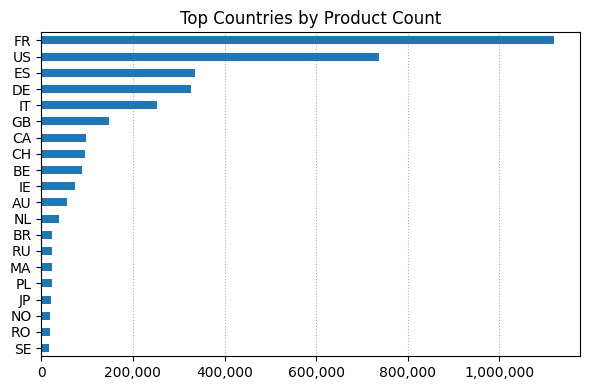

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax = top_cc[:20].plot.barh()

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
ax.set_axisbelow(True)

plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.title('Top Countries by Product Count')
plt.tight_layout()
plt.show()

### Confidence Criteria: Last Upload of an Ingredient Image

In [8]:
def last_image_upload(info: dict) -> pd.Timestamp:
  if isinstance(info, dict):
    # note: timestamp may be None, list may be empty after filtering
    ts_list = [v['uploaded_t'] for v in info.values() if v['uploaded_t'] is not None]
    last = max(ts_list) if ts_list else None
    return pd.Timestamp(last, unit='s') if last else None
  else:
    return None

age_categories = ["<1 yr", "1-2 yrs", "2-5 yrs", "5-10 yrs", ">10 yrs"]

def categorize_age(yrs: int) -> str:
  if pd.isna(yrs):
      return None

  if yrs == 0:
      return age_categories[0]
  elif yrs == 1:
      return age_categories[1]
  elif yrs < 5:
      return age_categories[2]
  elif yrs < 10:
      return age_categories[3]
  else:
      return age_categories[4]

last = df.images.apply(last_image_upload)
yrs = (pd.Timestamp.today() - last).dt.days.floordiv(365.25).astype("Int64")

df['image_age'] = yrs.apply(categorize_age)
df.image_age.value_counts(dropna=False)

image_age
None        2728538
5-10 yrs     535626
2-5 yrs      236243
1-2 yrs      123796
<1 yr        113429
>10 yrs       16093
Name: count, dtype: int64

In [9]:
cols = ['cc', 'image_age']
grouped = (
  df[cols]
  .explode('cc')
  .dropna(subset=['cc'])
  .groupby(cols, dropna=False)
  .size()
  .unstack()
  .fillna(0)
  .astype(int)
)
grouped.columns = grouped.columns.where(grouped.columns.notna(), 'N/A')

top_countries = grouped.drop(columns='N/A').sum(axis=1).sort_values(ascending=False).index
top_df = grouped.loc[top_countries].reindex(columns=[*age_categories, 'N/A'])

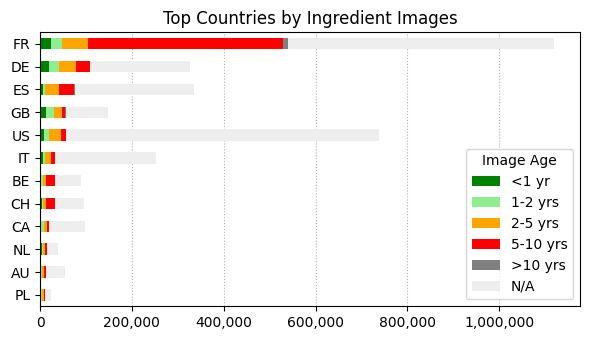

In [10]:
colors = ['green', 'lightgreen', 'orange', 'red', 'grey', '#eee']
fig, ax = plt.subplots(figsize=(6, 3.5))
top_df[:12].plot.barh(stacked=True, ax=ax, color=colors)

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.legend(title="Image Age")
plt.title('Top Countries by Ingredient Images')
plt.tight_layout()
plt.savefig("top_countries_ingredient_images.png");

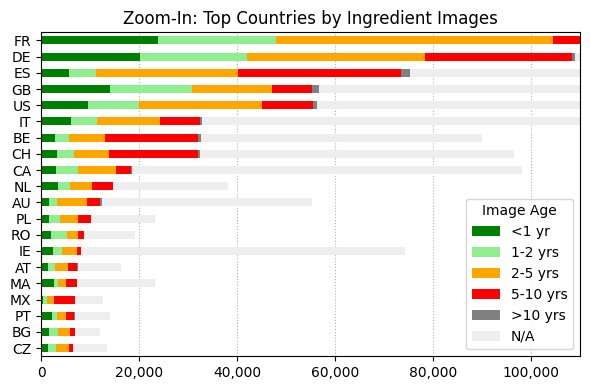

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
top_df[:20].plot.barh(stacked=True, ax=ax, color=colors)

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.xlim(0, 110000)
plt.legend(title="Image Age")
plt.title('Zoom-In: Top Countries by Ingredient Images')
plt.tight_layout()
plt.savefig("top_countries_ingredient_images_zoom.png");

## Confidence Criteria: Ratio of Known vs. Unknown Ingredients

In [12]:
def known_ratio(df: pd.DataFrame) -> pd.Series:
    known = df.known_ingredients_n
    unknown = df.unknown_ingredients_n
    total = known + unknown
    return (known / total).mask(total == 0, 0.0).mask(total.isna(), pd.NA)

In [13]:
ratio_categories = ["100%", ">=95%", ">=80%", "<80%", "0%"]

def categorize_ratio(ratio: float):
    if pd.isna(ratio):
        return None
    
    if ratio == 1:
        return ratio_categories[0]
    elif ratio >= 0.95:
        return ratio_categories[1]
    elif ratio >= 0.80:
        return ratio_categories[2]
    elif ratio == 0:
        return ratio_categories[4]
    else:
        return ratio_categories[3]

In [14]:
df['known_ratio'] = known_ratio(df).apply(categorize_ratio)
df['known_ratio'].value_counts(dropna=False)

known_ratio
None     2667403
100%      376285
>=80%     311810
>=95%     150507
<80%      139928
0%        107792
Name: count, dtype: int64

In [15]:
cols = ['cc', 'known_ratio']
grouped = (
  df[cols]
  .explode('cc')
  .dropna(subset=['cc'])
  .groupby(cols, dropna=False)
  .size()
  .unstack()
  .fillna(0)
  .astype('Int64')
)
grouped.columns = grouped.columns.where(grouped.columns.notna(), 'N/A')

top_countries = grouped.drop(columns='N/A').sum(axis=1).sort_values(ascending=False).index
top_df = grouped.loc[top_countries].reindex(columns=[*ratio_categories, 'N/A'])

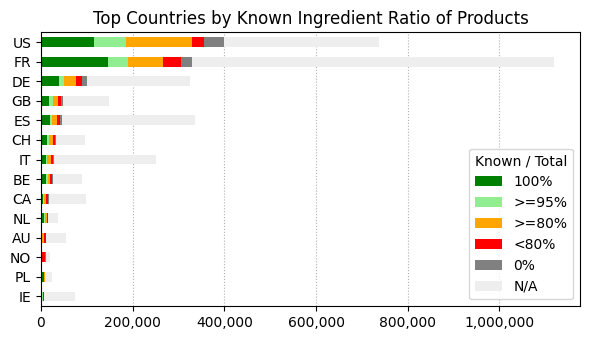

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))
top_df[:14].plot.barh(stacked=True, ax=ax, color=colors)

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

ax.set_axisbelow(True)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.legend(title="Known / Total")
plt.title('Top Countries by Known Ingredient Ratio of Products')
plt.tight_layout()
plt.savefig("top_countries_ingredient_ratio.png");

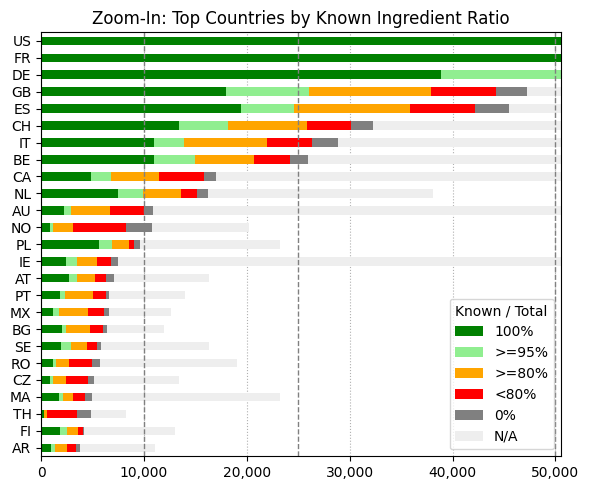

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
top_df[:25].plot.barh(stacked=True, ax=ax, color=colors)

ax.invert_yaxis()
ax.set_ylabel(None)
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')

plt.axvline(x=50000, linestyle='--', color='gray', linewidth=1)
plt.axvline(x=25000, linestyle='--', color='gray', linewidth=1)
plt.axvline(x=10000, linestyle='--', color='gray', linewidth=1)

ax.set_axisbelow(True)
plt.xlim(0, 50500)
plt.grid(axis='x', linestyle=':', linewidth=0.8)
plt.legend(title="Known / Total")
plt.title('Zoom-In: Top Countries by Known Ingredient Ratio')
plt.tight_layout()
plt.savefig("top_countries_ingredient_ratio_zoom.png");